In [219]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.style.use('~/styles/clarke-default.mplstyle')
from nestpy import nestpy
import trimesh
from scipy.stats import gaussian_kde

### Function to get S2 photons from energy using NEST

In [207]:
nc = nestpy.NESTcalc(nestpy.VDetector())

energy = 100.
A = 131.293
Z = 54.
density = 2.9 # g/cm^3
drift_field = 200. # V/cm
ph_per_elec = 50
ph_smearing = 0.25

def get_S2_photons(energy):
    NR_yields = nc.GetYields(nestpy.INTERACTION_TYPE(0), energy, density, drift_field)
    NR_quanta = nc.GetQuanta(NR_yields, density)
    n_elec = NR_quanta.electrons
    return int(np.random.normal(ph_per_elec*n_elec, ph_per_elec*ph_smearing))

### Load simulated data from Jingke

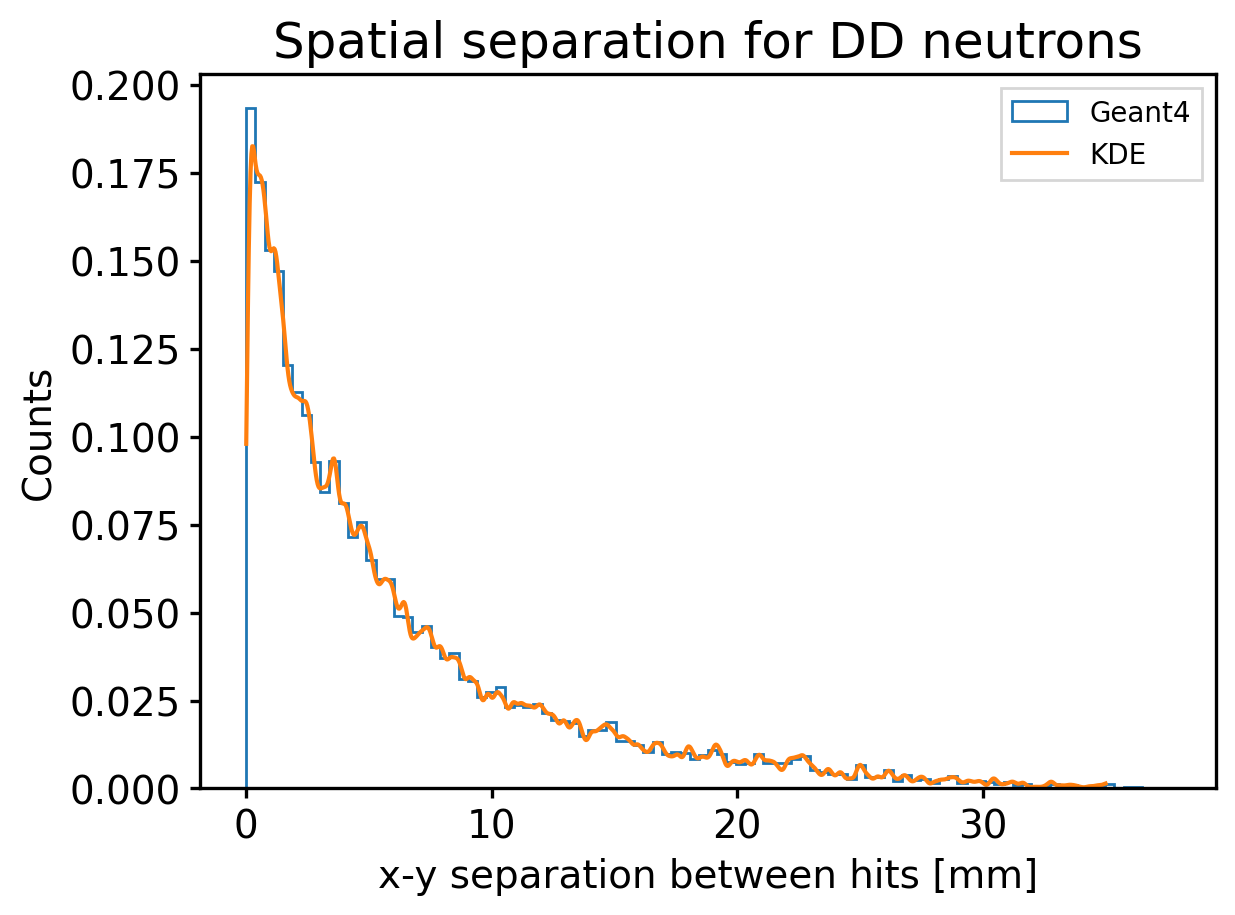

In [548]:
sim_data = np.genfromtxt('data/MS2TPC4keVDD.txt', skip_header=1)
sim_data.shape

def spatial_sep(pos, pos2):
    """Get the distance between two points in a MS event
    """
    return np.sqrt(np.sum(((pos - pos2)**2)[:,:2], axis=1))

pos1 = sim_data[:, 2:4]
pos2 = sim_data[:, 6:8]

seps = spatial_sep(pos1, pos2)
seps[np.isnan(seps)] = 0.

sep_kde = gaussian_kde(seps, 0.02)
sep_array = np.linspace(0, 35, 1000)

fig, ax = plt.subplots()
ax.hist(seps, histtype='step', bins=100, density=True, label='Geant4')
ax.plot(sep_array, sep_kde(sep_array), label='KDE')
ax.set_xlabel('x-y separation between hits [mm]')
ax.set_ylabel('Counts')
ax.set_title('Spatial separation for DD neutrons')
ax.legend()
fig.savefig('/home/clarke/figures/sim_data_seps.png')

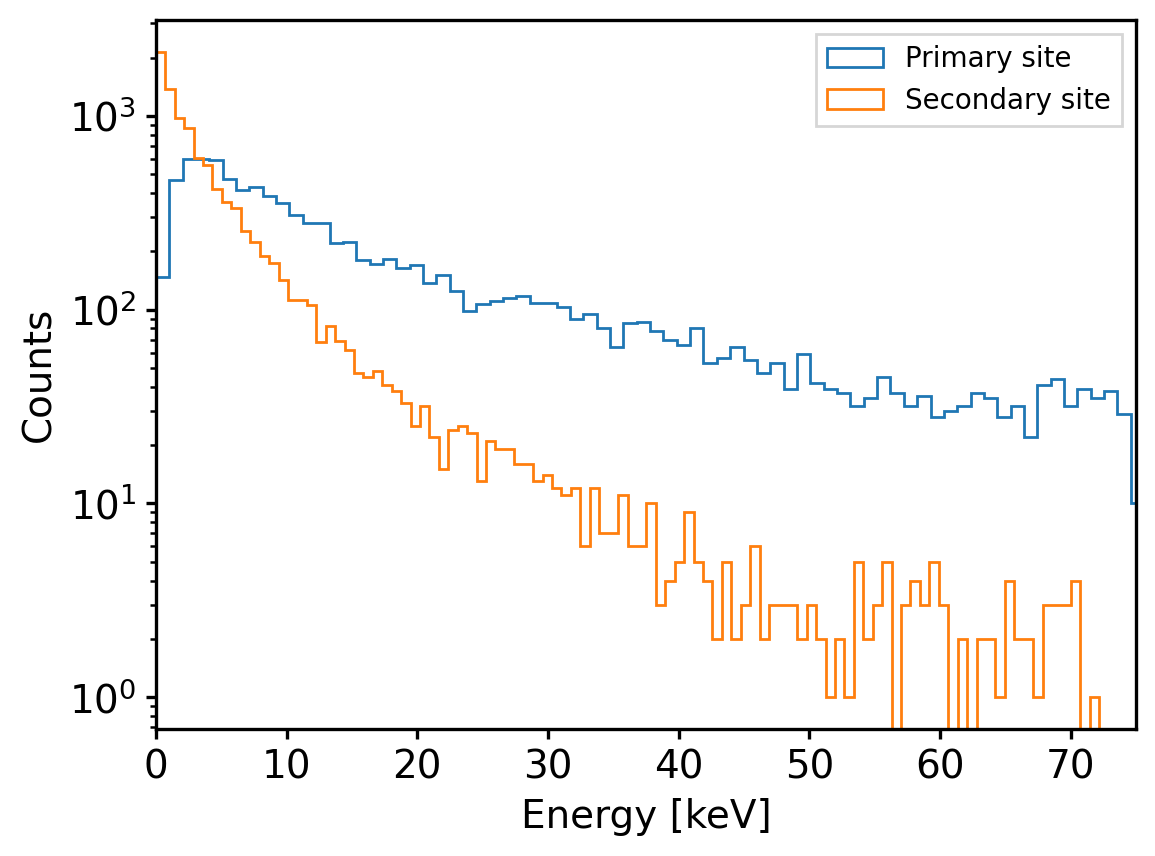

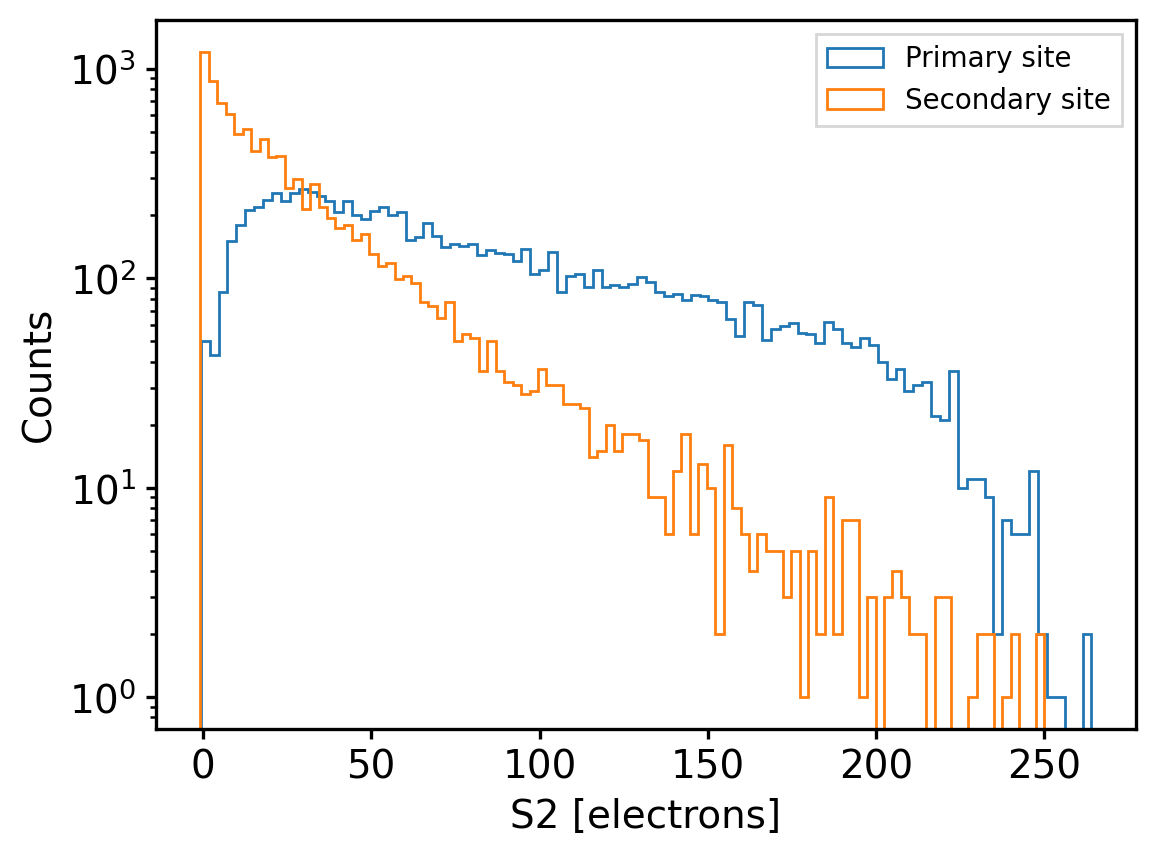

In [243]:
energy_1 = sim_data[:,1]
energy_2 = sim_data[:,5]
x_1 = sim_data[:,2]
y_1 = sim_data[:,3]
x_2 = sim_data[:,6]
y_2 = sim_data[:,7]

energy_l = np.amax(np.vstack((energy_1, energy_2)), axis=0)
energy_s = np.amin(np.vstack((energy_1, energy_2)), axis=0)

mask = energy_1 >= energy_2

x_l = np.where(mask, x_1, x_2)
x_s = np.where(mask, x_2, x_1)
y_l = np.where(mask, y_1, y_2)
y_s = np.where(mask, y_2, y_1)

fig, ax = plt.subplots(figsize=(6,4.5))
ax.hist(energy_l, histtype='step', bins=100, label='Primary site')
ax.hist(energy_s, histtype='step', bins=100, label='Secondary site')
ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Counts')
ax.legend()
ax.set_yscale('log')
ax.set_xlim([0, 75])
fig.savefig('/home/clarke/figures/sim_data_energy_partition.png')

s2_l = [get_S2_photons(i)/ph_per_elec for i in energy_l]
s2_s = [get_S2_photons(i)/ph_per_elec for i in energy_s]

fig, ax = plt.subplots(figsize=(6,4.5))
ax.hist(s2_l, histtype='step', bins=100, label='Primary site')
ax.hist(s2_s, histtype='step', bins=100, label='Secondary site')
ax.set_xlabel('S2 [electrons]')
ax.set_ylabel('Counts')
ax.legend()
ax.set_yscale('log')
#ax.set_xlim([0, 50])
fig.savefig('/home/clarke/figures/sim_data_electron_partition.png')

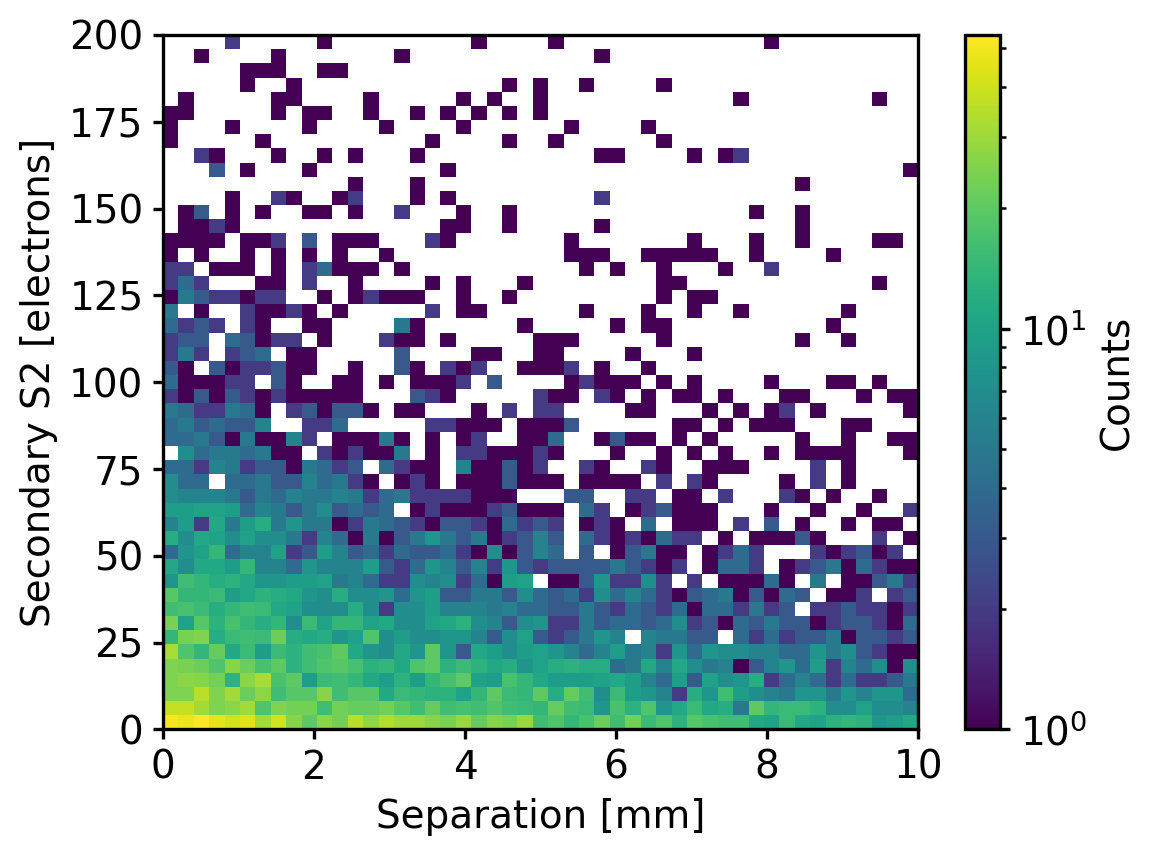

In [214]:
fig, ax = plt.subplots(figsize=(6, 4.5))

nbins = 50
h = ax.hist2d(seps, s2_s, bins=[np.linspace(0, 10, nbins), np.linspace(0, 200, nbins)], \
              norm=LogNorm())
ax.set_xlabel('Separation [mm]')
ax.set_ylabel('Secondary S2 [electrons]')
fig.colorbar(h[3], label='Counts')
fig.savefig('/home/clarke/figures/sim_data_electron_sep_2d.png')

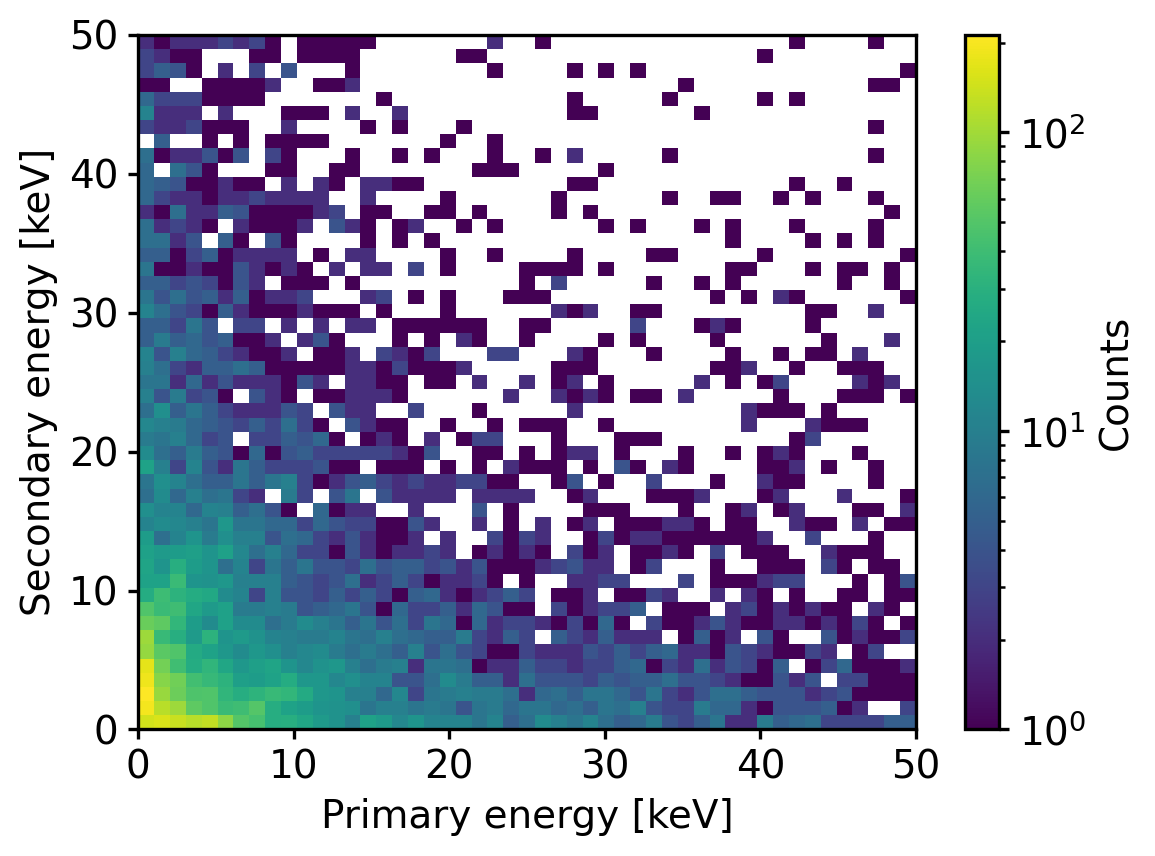

In [216]:
fig, ax = plt.subplots(figsize=(6, 4.5))

nbins = 50
h = ax.hist2d(energy_1, energy_2, bins=[np.linspace(0, 50, nbins), np.linspace(0, 50, nbins)], \
              norm=LogNorm())
ax.set_xlabel('Primary energy [keV]')
ax.set_ylabel('Secondary energy [keV]')
fig.colorbar(h[3], label='Counts')
# fig.savefig('/home/clarke/figures/sim_data_electron_sep_2d.png')

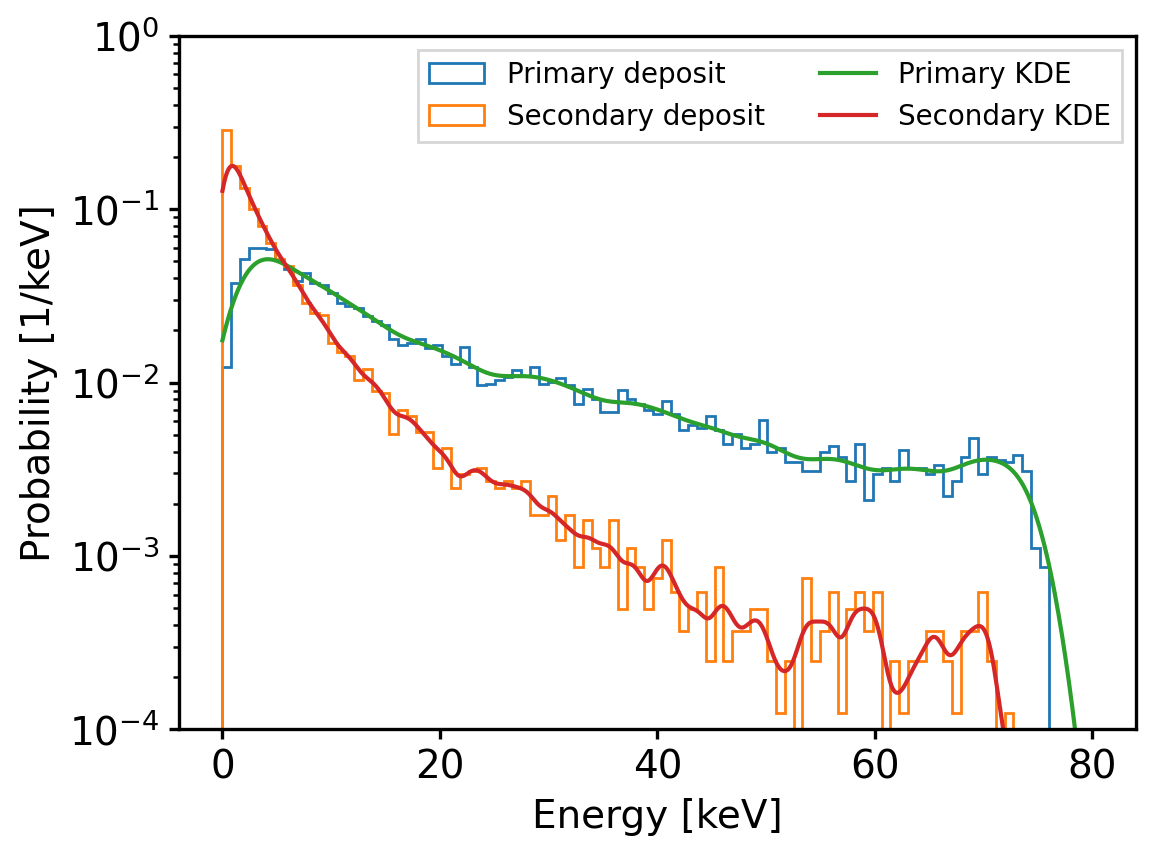

In [546]:
e_array = np.linspace(0, 80, 1000)
e_bins = np.linspace(np.amin(e_array), np.amax(e_array), 100)

bw_method = 0.1

e_kde_l = gaussian_kde(energy_l, bw_method=bw_method)
e_kde_s = gaussian_kde(energy_s, bw_method=bw_method)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(energy_l, bins=e_bins, density=True, histtype='step', label='Primary deposit')
ax.hist(energy_s, bins=e_bins, density=True, histtype='step', label='Secondary deposit')
ax.plot(e_array, e_kde_l(e_array), label='Primary KDE')
ax.plot(e_array, e_kde_s(e_array), label='Secondary KDE')
ax.set_yscale('log')
ax.set_ylim([1e-4, 1e0])
ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Probability [1/keV]')
ax.legend(ncol=2)
fig.savefig('/home/clarke/figures/energy_kde_1d.png')

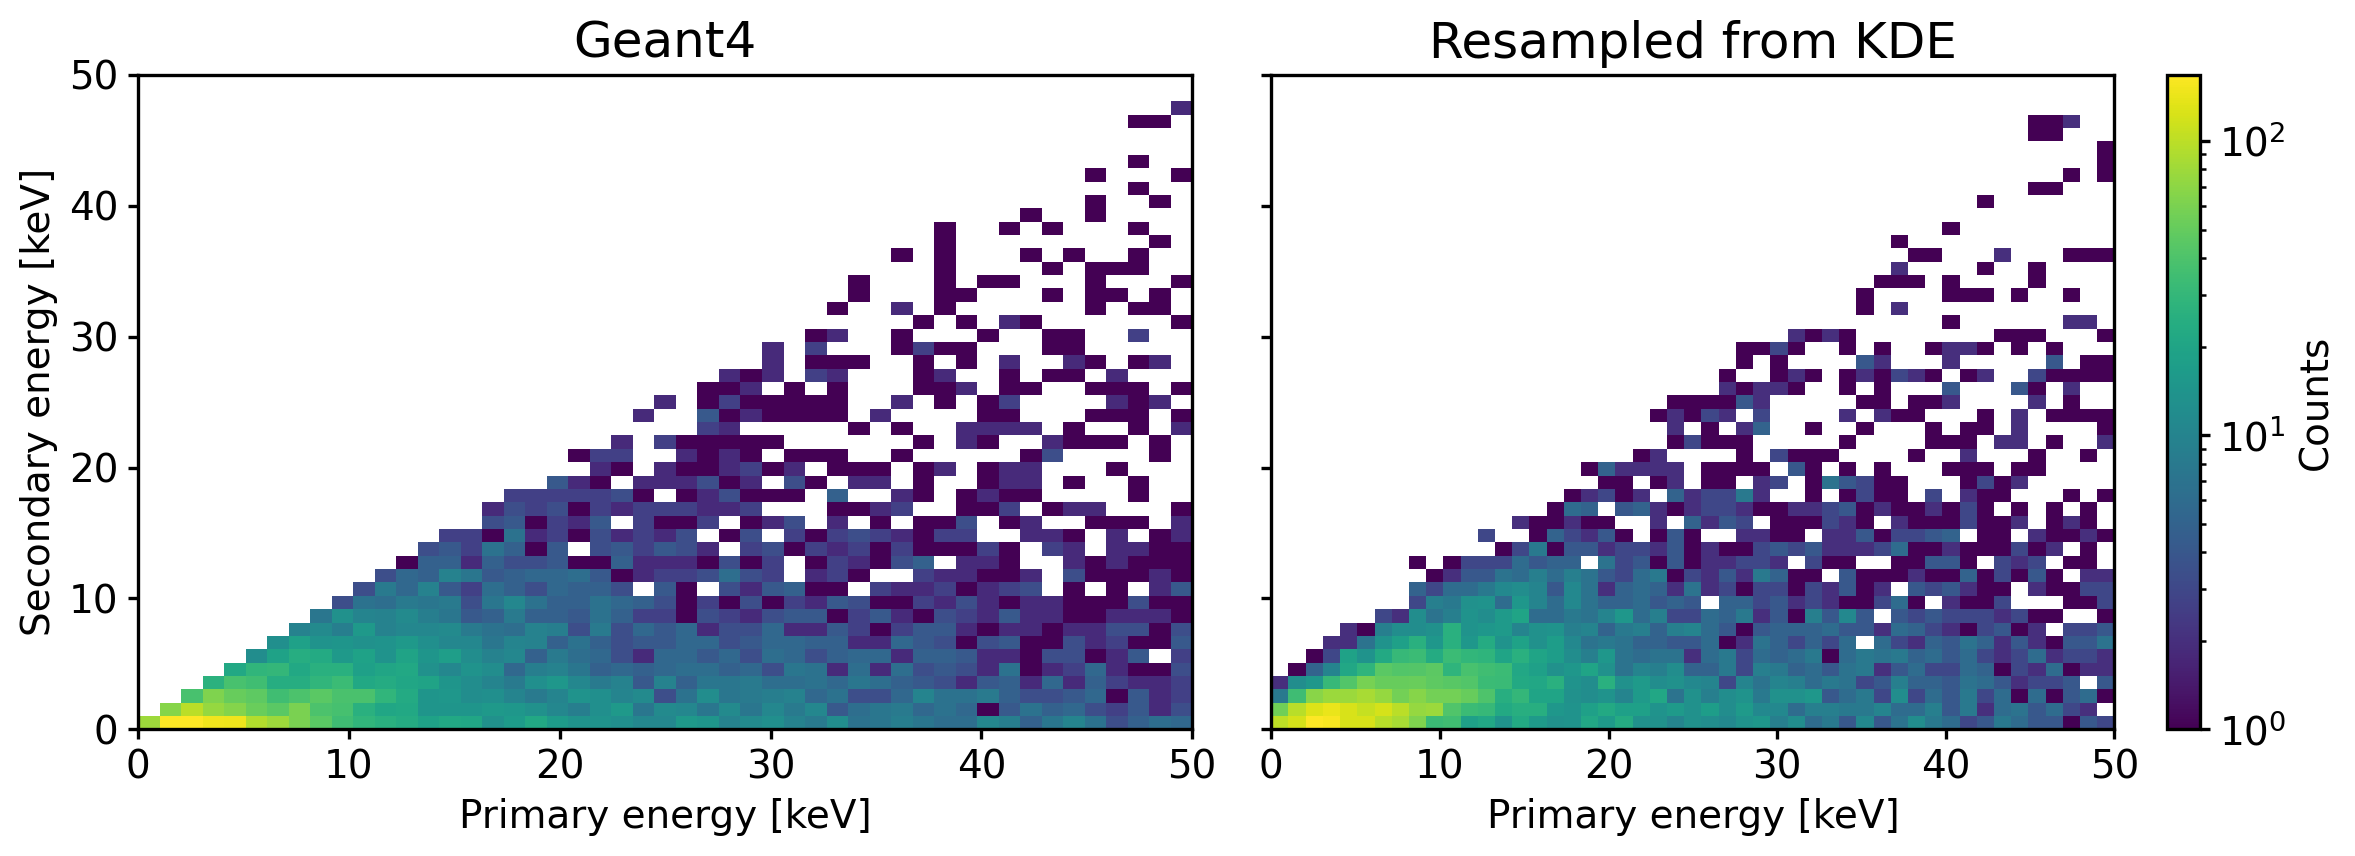

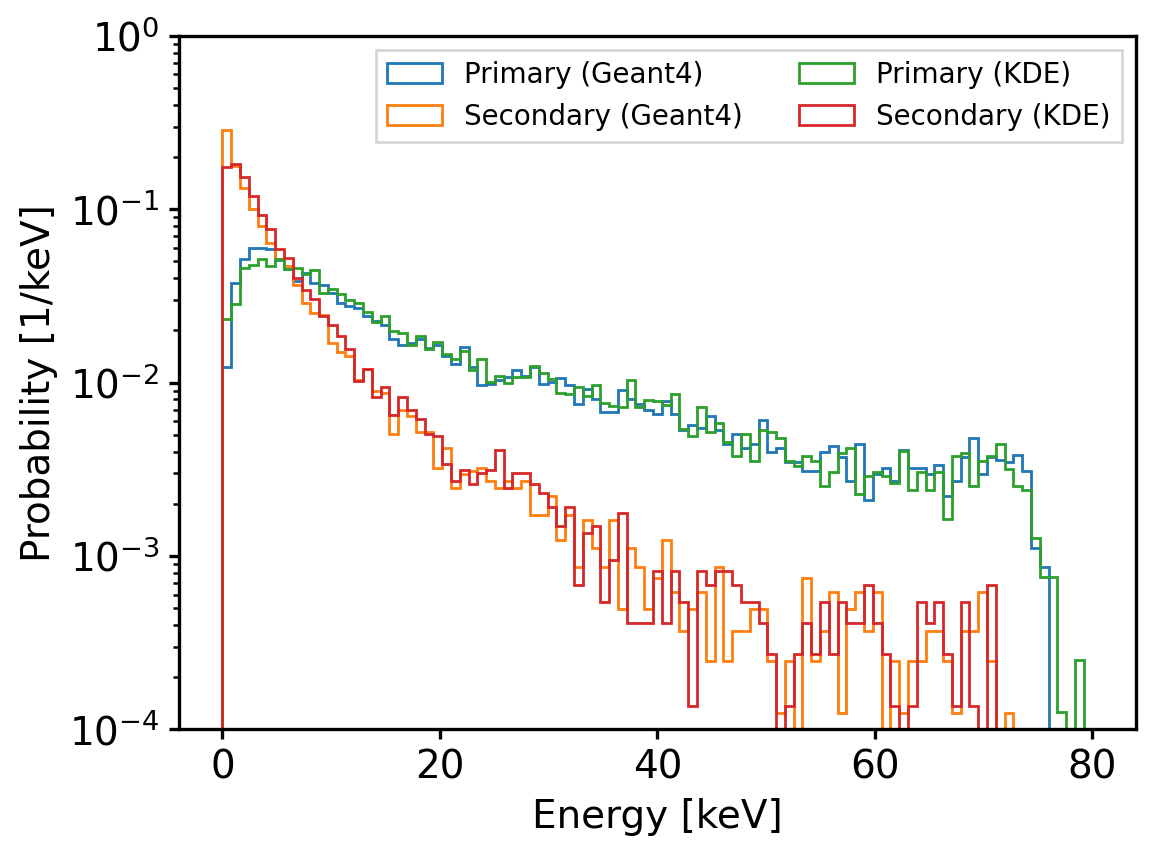

In [547]:
e_kde_both = gaussian_kde((energy_l, energy_s), 0.1)
samples_l, samples_s = e_kde_both.resample(10000)

# e_1d = np.linspace(0, 80, 100)
# e_2d = []

# for i in e_1d:
#     for j in e_1d:
#         e_2d.append([i, j])
# e_2d = np.array(e_2d)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
# ax.scatter(energy_l, energy_s, s=0.1)
# ax.scatter(samples_l, samples_s, s=0.1)
nbins = 50
h = ax[0].hist2d(energy_l, energy_s, bins=[np.linspace(0, 50, nbins), np.linspace(0, 50, nbins)], \
                 norm=LogNorm())
h = ax[1].hist2d(samples_l, samples_s, bins=[np.linspace(0, 50, nbins), np.linspace(0, 50, nbins)], \
                 norm=LogNorm())
ax[0].set_xlabel('Primary energy [keV]')
ax[0].set_title('Geant4')
ax[1].set_xlabel('Primary energy [keV]')
ax[0].set_ylabel('Secondary energy [keV]')
ax[1].set_title('Resampled from KDE')
fig.colorbar(h[3], label='Counts')
fig.savefig('/home/clarke/figures/energy_partitioning_2panels.png')

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(energy_l, bins=e_bins, density=True, histtype='step', label='Primary (Geant4)')
ax.hist(energy_s, bins=e_bins, density=True, histtype='step', label='Secondary (Geant4)')
ax.hist(samples_l, bins=e_bins, density=True, histtype='step', label='Primary (KDE)')
ax.hist(samples_s, bins=e_bins, density=True, histtype='step', label='Secondary (KDE)')
ax.set_yscale('log')
ax.set_ylim([1e-4, 1e0])
ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Probability [1/keV]')
ax.legend(ncol=2)
fig.savefig('/home/clarke/figures/energy_partitioning_resampled.png')

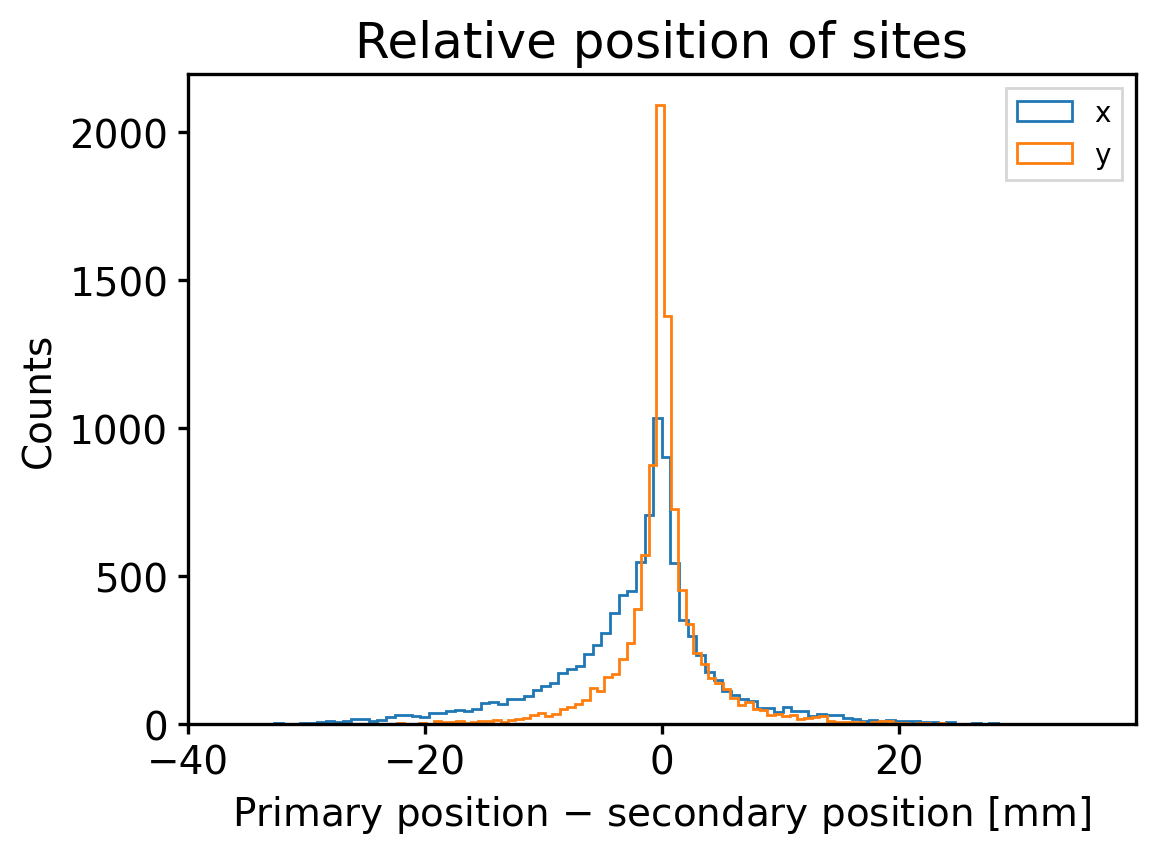

In [549]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(x_l - x_s, bins=100, histtype='step', label='x')
ax.hist(y_l - y_s, bins=100, histtype='step', label='y')
ax.set_xlabel('Primary position $-$ secondary position [mm]')
ax.set_ylabel('Counts')
ax.set_title('Relative position of sites')
ax.legend()
fig.savefig('/home/clarke/figures/relative_position_sites.png')

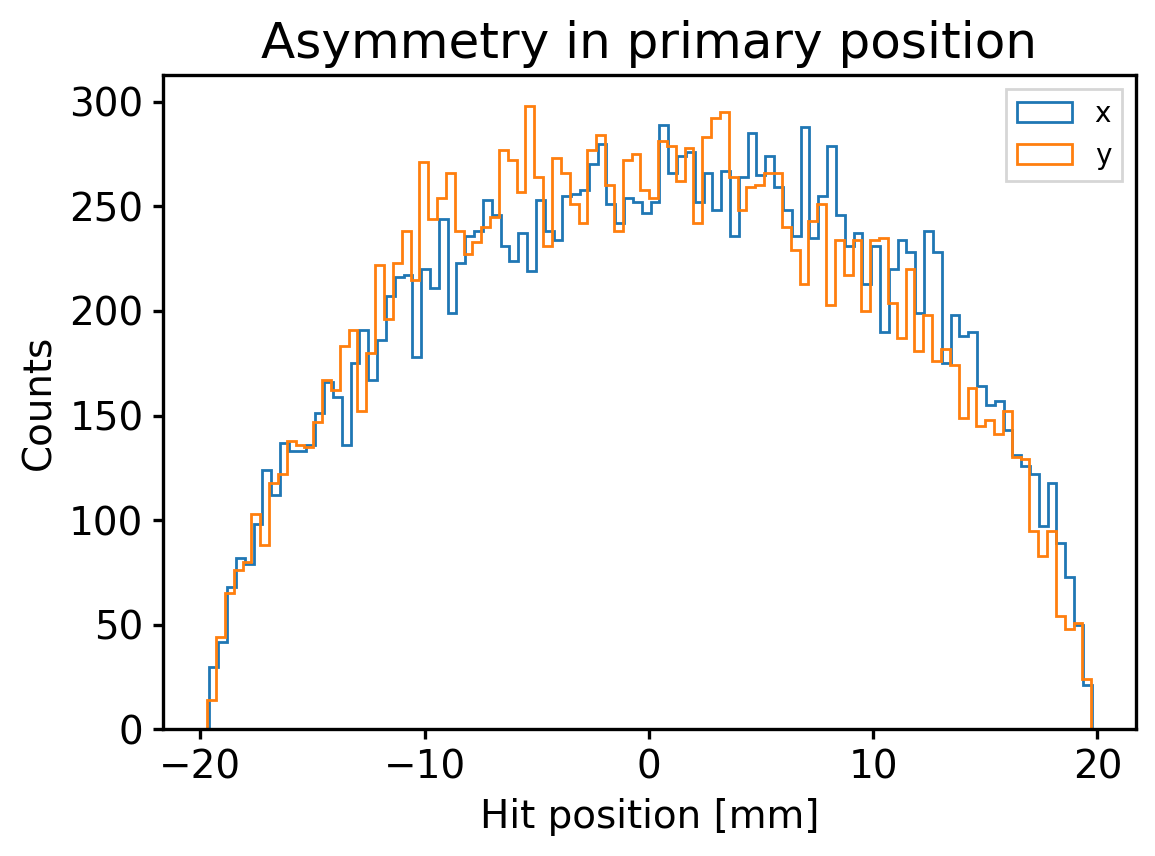

In [550]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(np.concatenate((x_l, x_s)), bins=100, histtype='step', label='x')
ax.hist(np.concatenate((y_l, y_s)), bins=100, histtype='step', label='y')
ax.set_xlabel('Hit position [mm]')
ax.set_ylabel('Counts')
ax.legend()
ax.set_title('Asymmetry in primary position')
fig.savefig('/home/clarke/figures/asymmetry_primary_pos.png')

In [261]:
np.corrcoef(energy_s, seps)

array([[ 1.        , -0.08747202],
       [-0.08747202,  1.        ]])

### Check that the x-y positions look correct

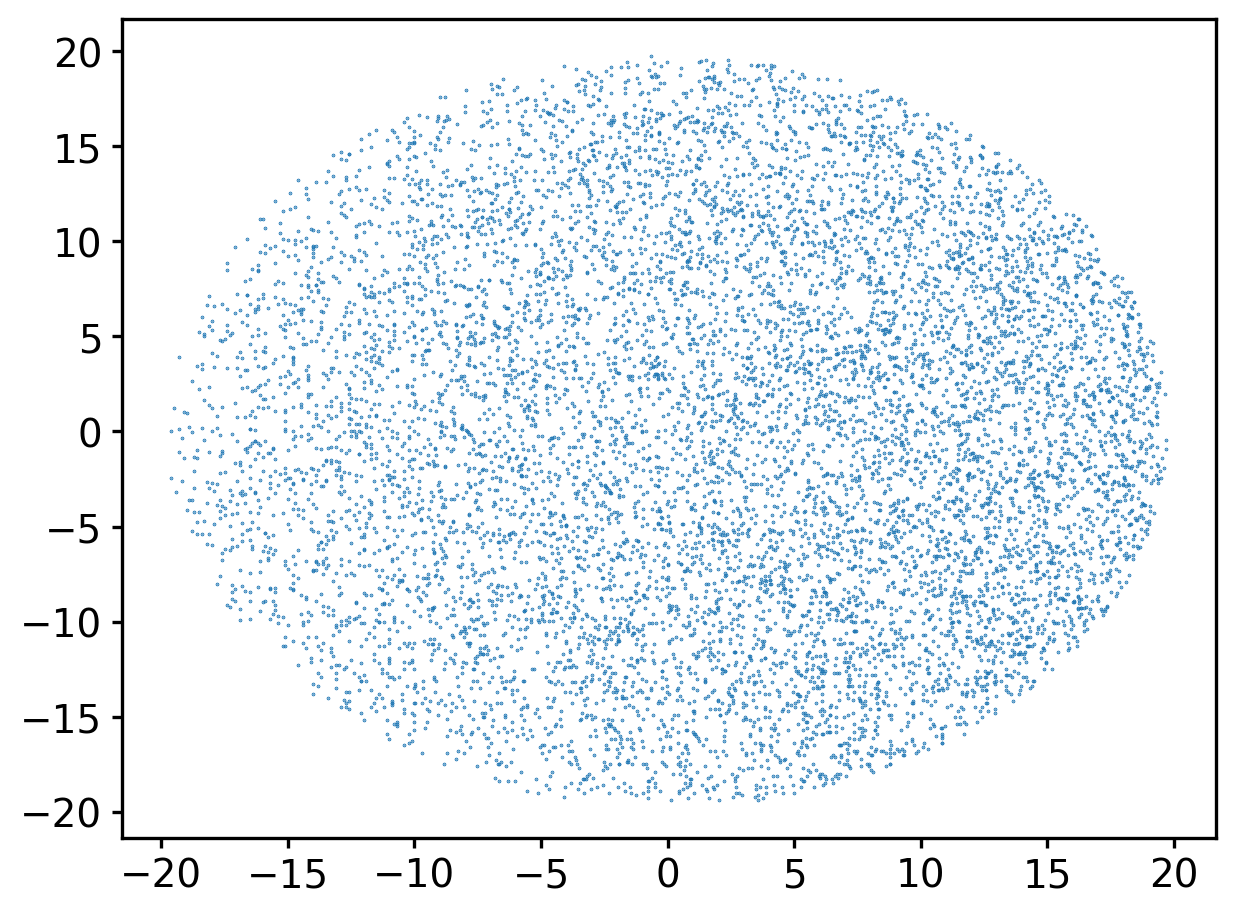

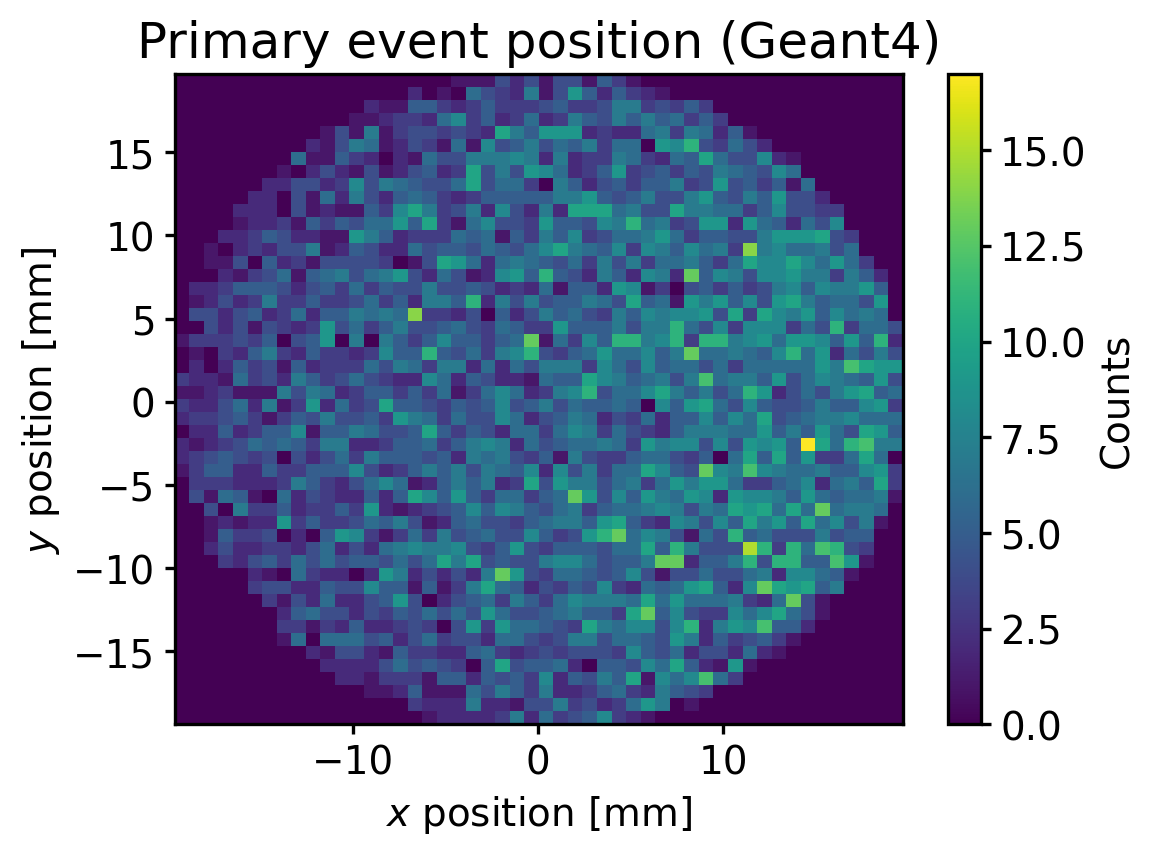

In [544]:
plt.scatter(sim_data[:, 2], sim_data[:, 3], s=0.1)

fig, ax = plt.subplots(figsize=(6, 4.5))
h = ax.hist2d(sim_data[:, 2], sim_data[:, 3], bins=50)
ax.set_xlabel('$x$ position [mm]')
ax.set_ylabel('$y$ position [mm]')
ax.set_title('Primary event position (Geant4)')
fig.colorbar(h[3], label='Counts')
fig.savefig('/home/clarke/figures/primary_pos_distribution_geant4.png')

### Find the z position to attach to the events at the liquid surface

In [268]:
# load the stl file defining the extraction region
# mesh = trimesh.load_mesh('/home/clarke/stl/ExtractionRegion.stl')
mesh = trimesh.load_mesh('/home/clarke/stl/LXe.stl')
vertices = mesh.vertices

# offset to bring extraction region to its actual size
z_offset = 6.493

# find the coordinates and radius
min_z = np.min(vertices[:, 2])
max_z = np.max(vertices[:, 2])

z_pos = max_z + z_offset
print(z_pos)

# find the coordinates and radius
min_z = np.min(vertices[:, 2])
max_z = np.max(vertices[:, 2])
bottom_points = vertices[np.isclose(vertices[:, 2], min_z)]
top_points = vertices[np.isclose(vertices[:, 2], max_z)]
bottom_center = np.mean(bottom_points, axis=0)
top_center = np.mean(top_points, axis=0)
radius = np.mean(np.linalg.norm(bottom_points[:,:2] - bottom_center[:2], axis=1))
height = max_z - min_z

def create_points(n_points=10_000):
    points_rt = np.random.uniform([0., 0.], [radius**2, 2.*np.pi], size=(n_points, 2))
    points_rt[:, 0] = np.sqrt(points_rt[:, 0])
    points_rtz = np.hstack([points_rt, (max_z + z_offset)*np.ones(n_points)[:, np.newaxis]])

    points_xyz = np.zeros_like(points_rtz)
    points_xyz[:, 0] = points_rtz[:, 0] * np.cos(points_rtz[:, 1])
    points_xyz[:, 1] = points_rtz[:, 0] * np.sin(points_rtz[:, 1])
    points_xyz[:, 2] = points_rtz[:, 2]
    return points_xyz

-379.2625847167969


### Save the positions and associated S2s

In [270]:
def create_ms_events(sim_data, prefix, s2_cut=1):
    s2_photons_site1 = np.zeros(sim_data.shape[0])
    s2_photons_site2 = np.zeros(sim_data.shape[0])
    for i, line in enumerate(sim_data):
        s2_photons_site1[i] = get_S2_photons(line[1])
        s2_photons_site2[i] = get_S2_photons(line[5])
    mask = (s2_photons_site1 > s2_cut) & (s2_photons_site2 > s2_cut)
    points1 = np.hstack((sim_data[:, 2:4][mask], \
                         np.ones((len(sim_data), 1))[mask]*z_pos, \
                         s2_photons_site1[:, None][mask]))
    points2 = np.hstack((sim_data[:, 6:8][mask], \
                         np.ones((len(sim_data), 1))[mask]*z_pos, \
                         s2_photons_site2[:, None][mask]))
    np.save(prefix + '_site1.npy', points1, allow_pickle=False)
    np.save(prefix + '_site2.npy', points2, allow_pickle=False)

def create_ss_events(sim_data, prefix, s2_cut=1):
    s2_photons = np.zeros(sim_data.shape[0])
    for i, line in enumerate(sim_data):
        s2_photons[i] = get_S2_photons(line[1] + line[5])
    mask = (s2_photons > s2_cut)
    # points = np.hstack((create_points(len(sim_data))[mask], \
    #                     s2_photons[:, None][mask]))
    # switch from generating points to using site 1
    points = np.hstack((sim_data[:, 2:4][mask] + \
                        np.random.normal(0, 0.1, np.shape(sim_data[:, 2:4][mask])), \
                        np.ones((len(sim_data), 1))[mask]*z_pos, \
                        s2_photons[:, None][mask]))
    np.save(prefix + '_site0.npy', points, allow_pickle=False)

save_prefix = 'chroma-lxe/data/XeNu_LXe_surface_points_JingkeSim_2'

create_ms_events(sim_data, save_prefix)
create_ss_events(sim_data, save_prefix)

### Resample and generate more events
Plan for generating fake events:
 - Take x and y randomly from the TPC surface
 - Sample larger and smaller energy based on 2d KDE
 - Sample separation based on 1d KDE
 - Generate random angle from 0-2*pi
 - Get secondary x and y at the angle from the first
 - Remove events with an energy deposition outside the TPC

In [322]:
num_synth_events = int(2e4)

synth_pos = create_points(num_synth_events)
synth_seps = sep_kde.resample(num_synth_events)
synth_energies = e_kde_both.resample(num_synth_events)
synth_angles = np.random.uniform(0, 2*np.pi, num_synth_events)
synth_x2 = (synth_pos[:,0] + synth_seps*np.cos(synth_angles))[0]
synth_y2 = (synth_pos[:,1] + synth_seps*np.sin(synth_angles))[0]

mask = (np.abs(synth_x2) <= np.abs(synth_pos[:, 0])) \
        & (np.abs(synth_y2) <= np.abs(synth_pos[:, 1]))

synth_data = np.vstack((np.arange(sum(mask)), synth_energies[0][mask], \
                        synth_pos[:, 0][mask], synth_pos[:, 1][mask], \
                        synth_pos[:, 2][mask], synth_energies[1][mask], \
                        synth_x2[mask], synth_y2[mask], synth_pos[:, 2][mask])).T

save_prefix = 'chroma-lxe/data/XeNu_LXe_surface_points_JingkeResampled'

# create_ms_events(synth_data, save_prefix, s2_cut=15)
# create_ss_events(synth_data, save_prefix, s2_cut=15)

Text(0, 0.5, 'y [mm]')

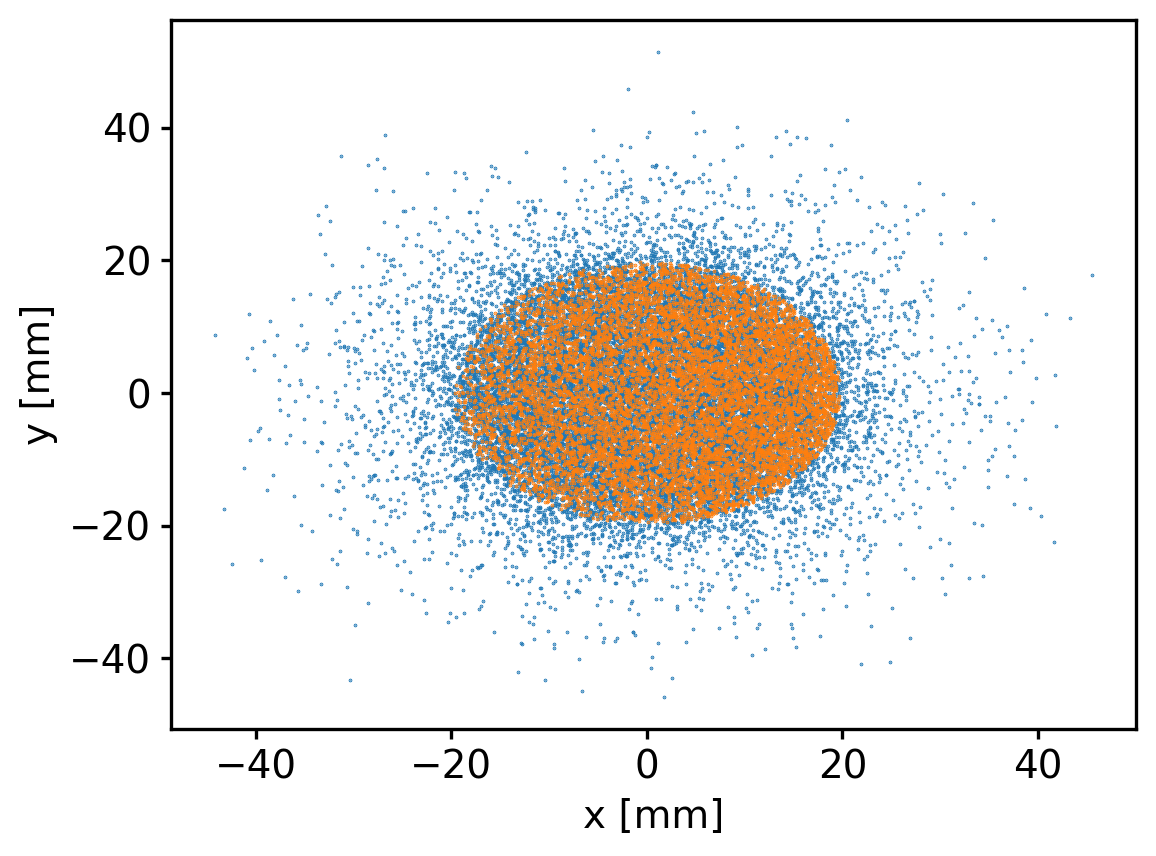

In [ ]:
# see where the second sites were created
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(synth_x2, synth_y2, s=0.1)
ax.scatter(sim_data[:, 2], sim_data[:, 3], s=0.1)
ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_s

(335039, 4)


(array([2.206e+03, 2.375e+03, 3.008e+03, 3.800e+03, 4.578e+03, 5.457e+03,
        6.379e+03, 6.876e+03, 7.420e+03, 7.669e+03, 7.857e+03, 8.092e+03,
        8.075e+03, 8.464e+03, 8.379e+03, 8.318e+03, 8.137e+03, 7.745e+03,
        7.683e+03, 7.497e+03, 7.324e+03, 7.342e+03, 7.164e+03, 6.791e+03,
        6.415e+03, 6.158e+03, 5.790e+03, 5.641e+03, 5.537e+03, 5.497e+03,
        5.388e+03, 4.927e+03, 4.724e+03, 4.576e+03, 4.399e+03, 4.252e+03,
        4.276e+03, 4.235e+03, 4.132e+03, 3.980e+03, 3.930e+03, 3.753e+03,
        3.699e+03, 3.676e+03, 3.736e+03, 3.600e+03, 3.466e+03, 3.472e+03,
        3.269e+03, 3.230e+03, 3.051e+03, 3.069e+03, 3.033e+03, 2.841e+03,
        2.863e+03, 2.771e+03, 2.588e+03, 2.462e+03, 2.400e+03, 2.293e+03,
        2.194e+03, 2.216e+03, 2.140e+03, 2.003e+03, 2.030e+03, 1.829e+03,
        1.883e+03, 1.887e+03, 1.796e+03, 1.737e+03, 1.821e+03, 1.629e+03,
        1.500e+03, 1.361e+03, 1.257e+03, 1.105e+03, 9.740e+02, 8.200e+02,
        6.600e+02, 5.640e+02, 4.380e+0

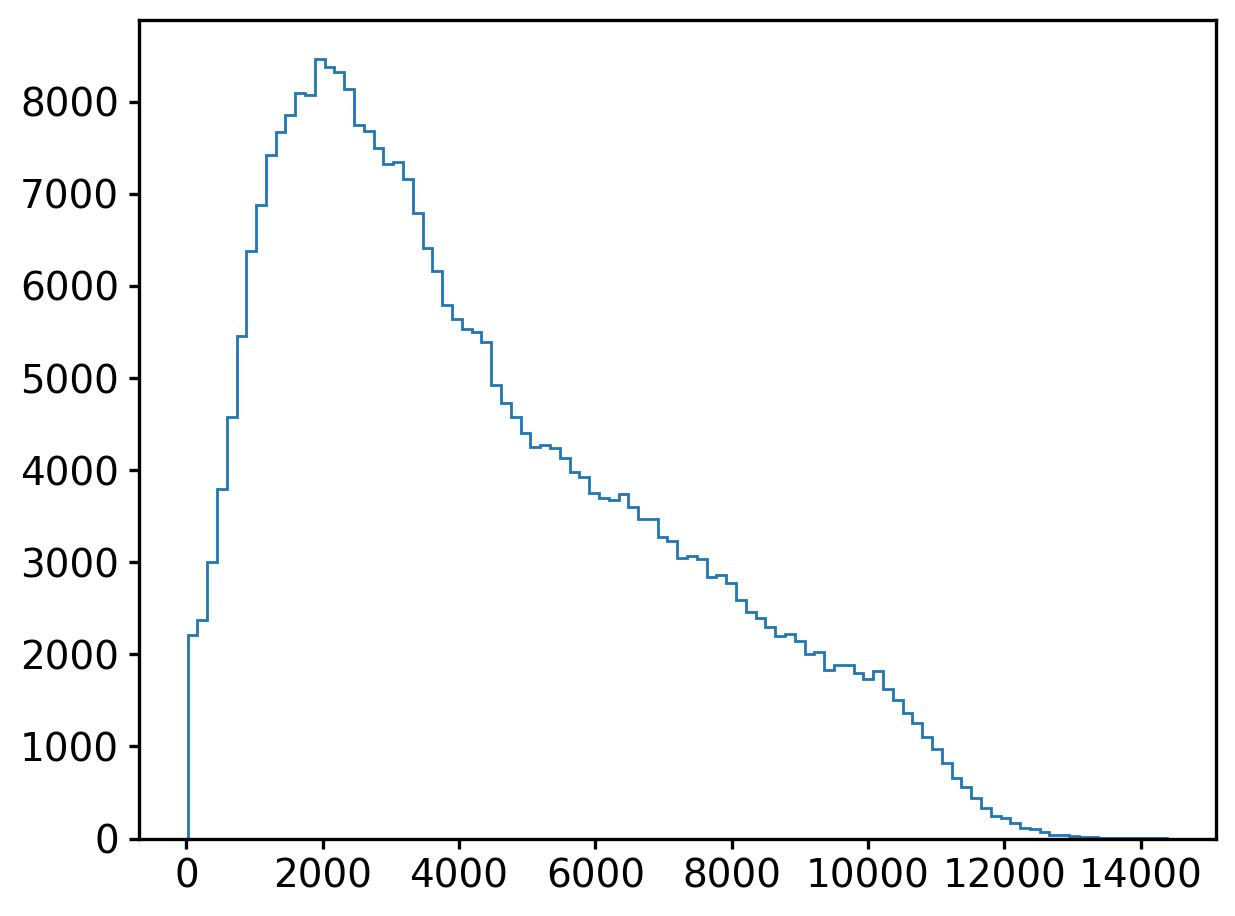

In [319]:
d = np.load('chroma-lxe/data/XeNu_LXe_surface_points_JingkeResampled_site1.npy')
print(d.shape)
plt.hist(d[:, 3], histtype='step', bins=100)

Text(0.5, 1.0, 'x-y separation between hits')

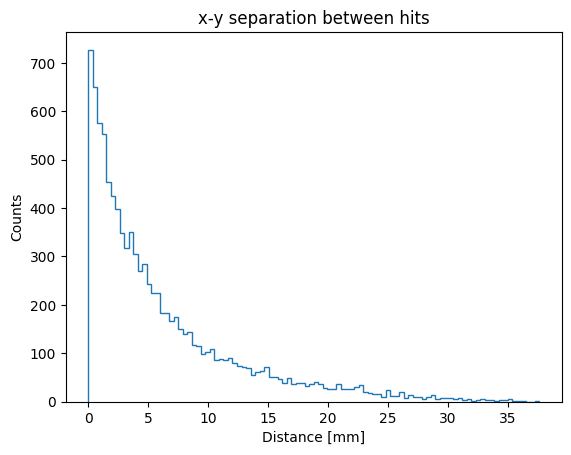

In [90]:
def spatial_sep(pos, pos2):
    """Get the distance between two points in a MS event
    """
    return np.sqrt(np.sum(((pos - pos2)**2)[:,:2], axis=1))

pos1 = sim_data[:, 2:4]
pos2 = sim_data[:, 6:8]

seps = spatial_sep(pos1, pos2)

fig, ax = plt.subplots()
ax.hist(seps, histtype='step', bins=100)
ax.set_xlabel('Distance [mm]')
ax.set_ylabel('Counts')
ax.set_title('x-y separation between hits')

(0.0, 20.0)

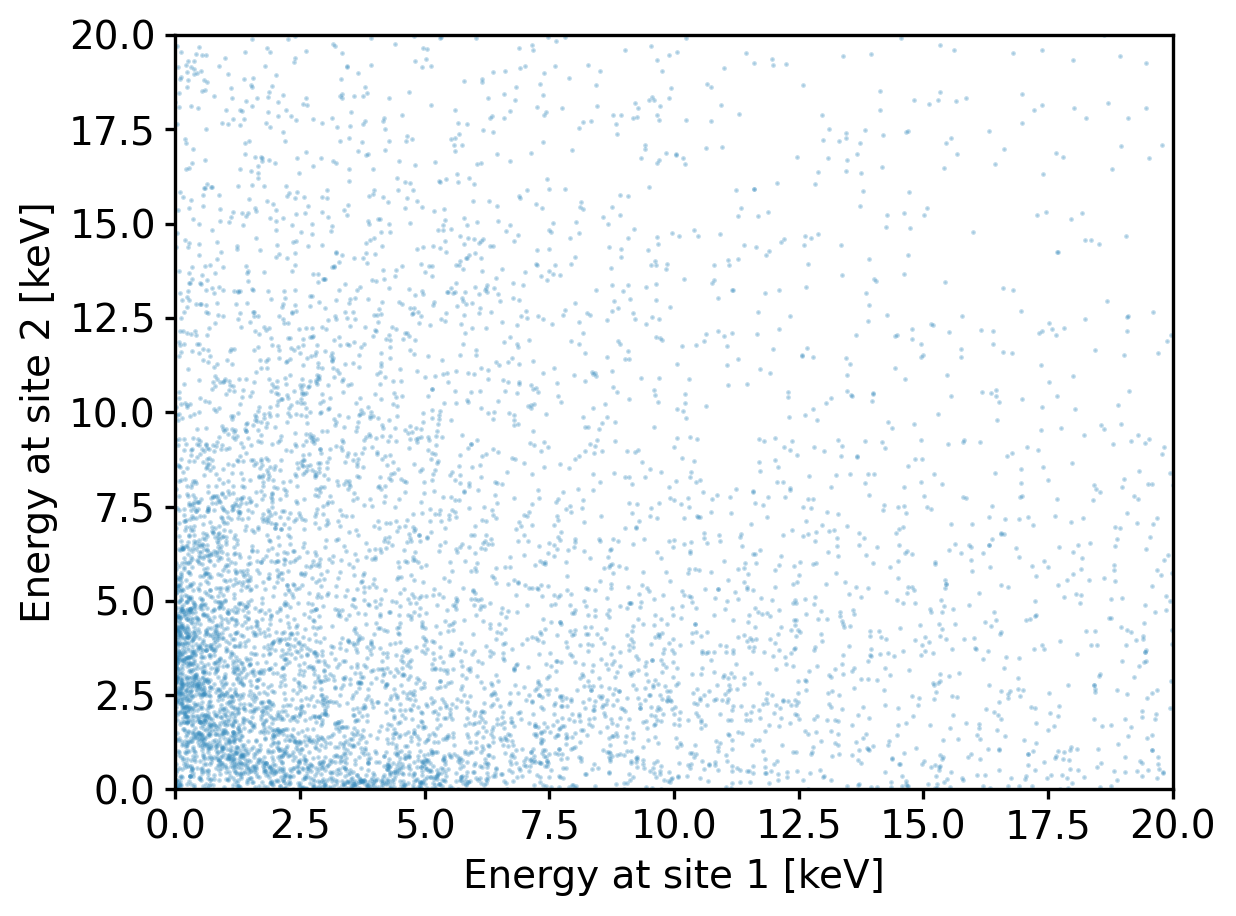

In [105]:
fig, ax = plt.subplots()
ax.scatter(sim_data[:,1], sim_data[:,5], marker='.', s=2, alpha=0.3)
ax.set_xlabel('Energy at site 1 [keV]')
ax.set_ylabel('Energy at site 2 [keV]')
ax.set_xlim([0, 20])
ax.set_ylim([0, 20])

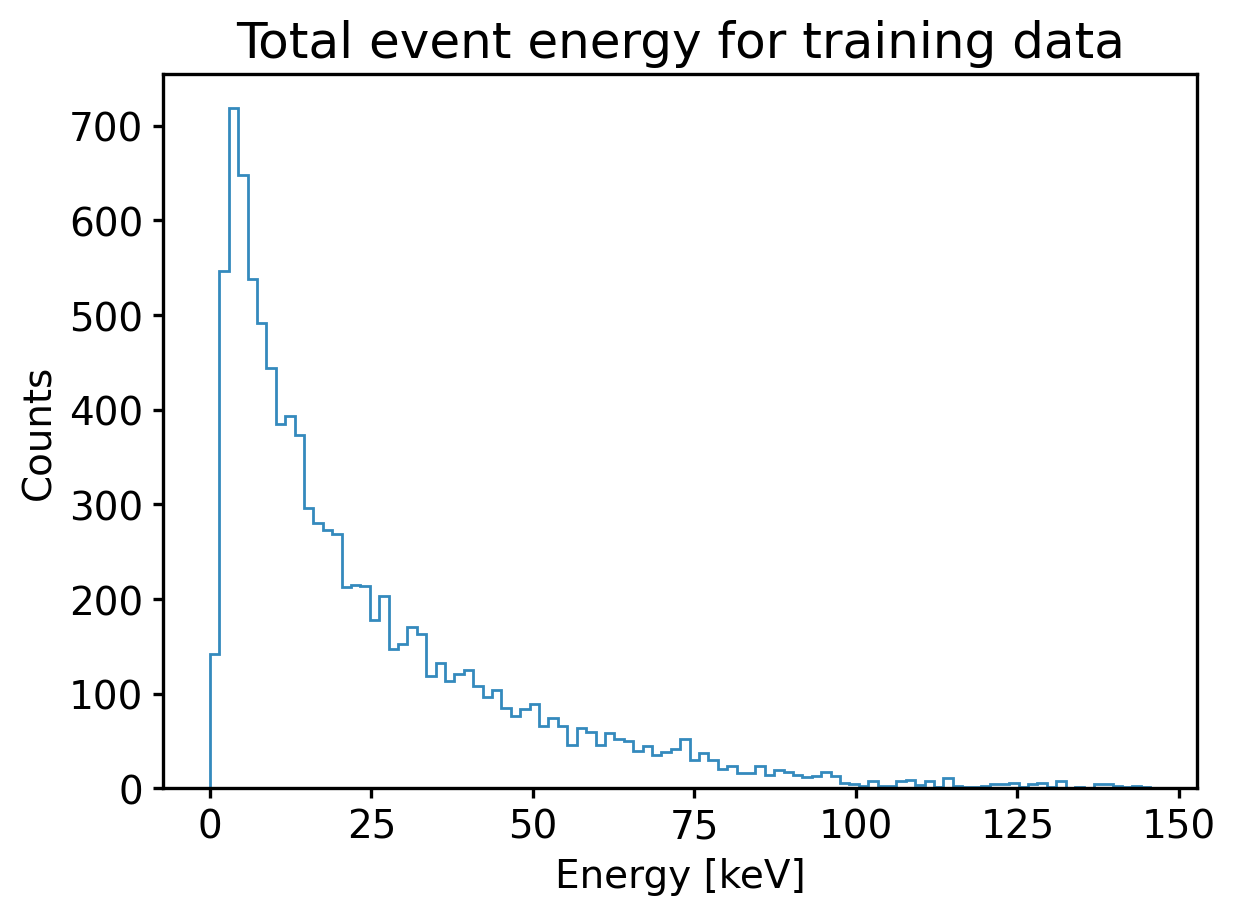

In [108]:
fig, ax = plt.subplots()
ax.hist(sim_data[:,1] + sim_data[:,5],histtype='step', bins=100)
ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Counts')
ax.set_title('Total event energy for training data')
# ax.set_xlim([0, 20])
# ax.set_ylim([0, 20])
fig.savefig('/home/clarke/figures/sim_data_spec.png')